# Model 3 — CNN-LSTM (RNN/LSTM, Patch-Sequence)

**Owner:** Shashwat Chandore (230953304)

> **Depends on:** run `00_shared_pipeline.ipynb` first, in the same kernel (it builds `train_df`/`val_df`/`test_df`, the DataLoaders, `pos_weights`, `criterion`, and the shared `train_model`/`evaluate` functions used below).

## Architecture

Represents the recurrent family. The image is divided into a grid of patches, each patch is embedded by a small shared CNN, and the resulting sequence of patch embeddings is fed through an LSTM so each patch’s representation is conditioned on the ones already seen in sequence; the final hidden state goes to the classification head. Trained from scratch (no pretrained backbone).

In [1]:
# --- Model 3: CNN-LSTM (RNN/LSTM — patch sequence) ---
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=5, patch_size=32, img_size=224, hidden_size=128):
        super().__init__()
        assert img_size % patch_size == 0
        self.patch_size = patch_size
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B = x.size(0)
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.contiguous().view(B, 3, -1, p, p).permute(0, 2, 1, 3, 4)
        N = patches.size(1)
        feats = [self.cnn(patches[:, i]).view(B, -1) for i in range(N)]
        seq = torch.stack(feats, dim=1)
        _, (h_n, _) = self.lstm(seq)
        return self.fc(h_n[-1])

print("CNN-LSTM params:", sum(p.numel() for p in CNNLSTM().parameters()))

CNN-LSTM params: 88677


## Sanity-Check Patch Logic (before committing to a full training run)

In [2]:
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
test_model = CNNLSTM()
out = test_model(dummy)
print(f"CNN-LSTM output shape: {out.shape}  (expected: [2, {len(DISEASE_COLS)}])")

CNN-LSTM output shape: torch.Size([2, 5])  (expected: [2, 5])


## Train

Note: noticeably slower per epoch than the other three (49 sequential CNN passes per image at `patch_size=32` on a 224x224 image) — this is expected.

In [3]:
cnnlstm_model = CNNLSTM(num_classes=len(DISEASE_COLS), img_size=IMG_SIZE)
cnnlstm_model, cnnlstm_history = train_model(cnnlstm_model, 'cnnlstm', freeze_schedule=False)

[cnnlstm] Epoch 1/5  Train Loss: 1.0299  Train AUC: 0.5721  Val Loss: 0.9964  Val AUC: 0.6426
[cnnlstm] Epoch 2/5  Train Loss: 0.9880  Train AUC: 0.6490  Val Loss: 0.9822  Val AUC: 0.6574
[cnnlstm] Epoch 3/5  Train Loss: 0.9787  Train AUC: 0.6607  Val Loss: 0.9685  Val AUC: 0.6686
[cnnlstm] Epoch 4/5  Train Loss: 0.9725  Train AUC: 0.6683  Val Loss: 0.9641  Val AUC: 0.6728
[cnnlstm] Epoch 5/5  Train Loss: 0.9682  Train AUC: 0.6731  Val Loss: 0.9616  Val AUC: 0.6749


In [29]:
with open(os.path.join(OUTPUT_DIR, 'cnnlstm_history.json'), 'w') as f:
    json.dump(cnnlstm_history, f)

## Evaluate on Test Set

In [5]:
_, cnnlstm_test_auc, cnnlstm_test_labels, cnnlstm_test_preds = evaluate(cnnlstm_model, test_loader, criterion)
print(f"CNN-LSTM Test Mean AUC: {cnnlstm_test_auc:.4f}")

CNN-LSTM Test Mean AUC: 0.6743


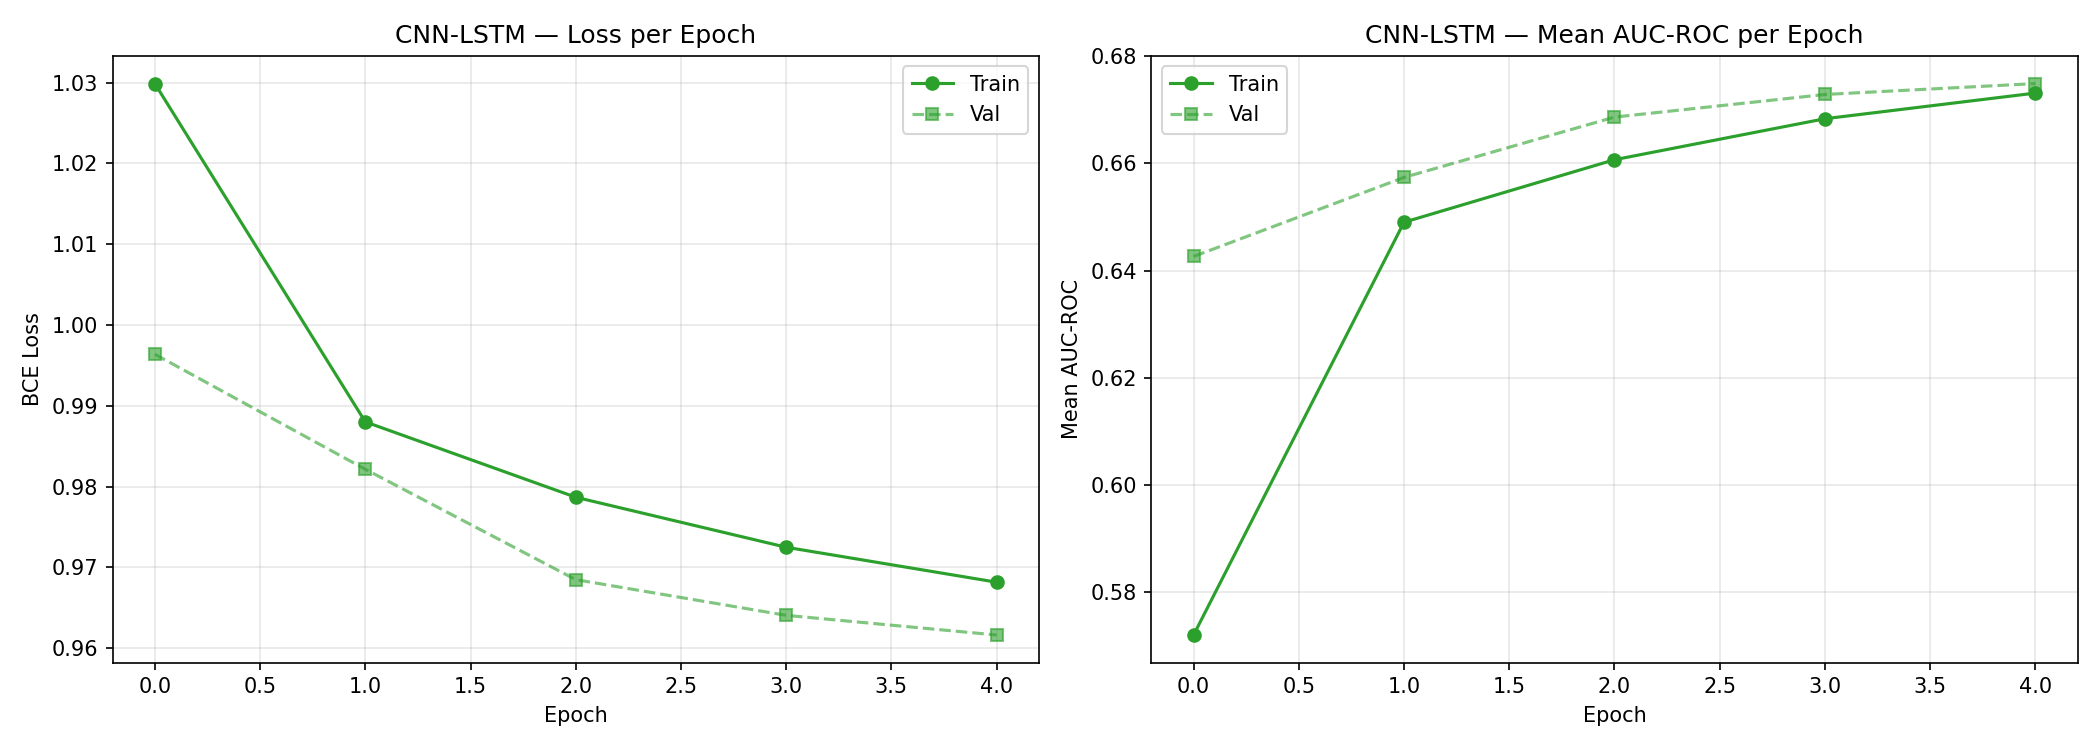

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cnnlstm_history['train_loss'], marker='o', label='Train', color='tab:green')
axes[0].plot(cnnlstm_history['val_loss'], marker='s', label='Val', color='tab:green', alpha=0.6, linestyle='--')
axes[0].set_title('CNN-LSTM — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(cnnlstm_history['train_auc'], marker='o', label='Train', color='tab:green')
axes[1].plot(cnnlstm_history['val_auc'], marker='s', label='Val', color='tab:green', alpha=0.6, linestyle='--')
axes[1].set_title('CNN-LSTM — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_loss_auc_curves.png'), dpi=150)
plt.show()

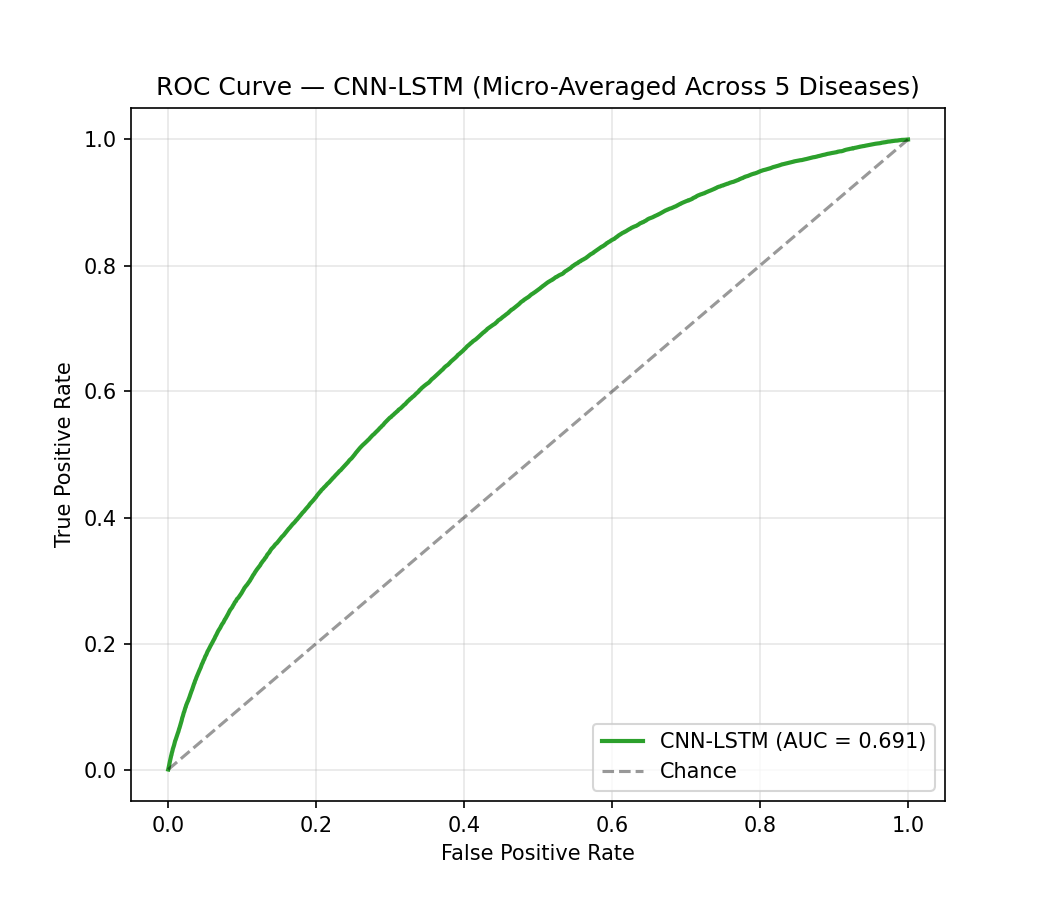

In [7]:
fpr, tpr, _ = roc_curve(cnnlstm_test_labels.ravel(), cnnlstm_test_preds.ravel())
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'CNN-LSTM (AUC = {roc_auc:.3f})', color='tab:green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CNN-LSTM (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_roc.png'), dpi=150)
plt.show()

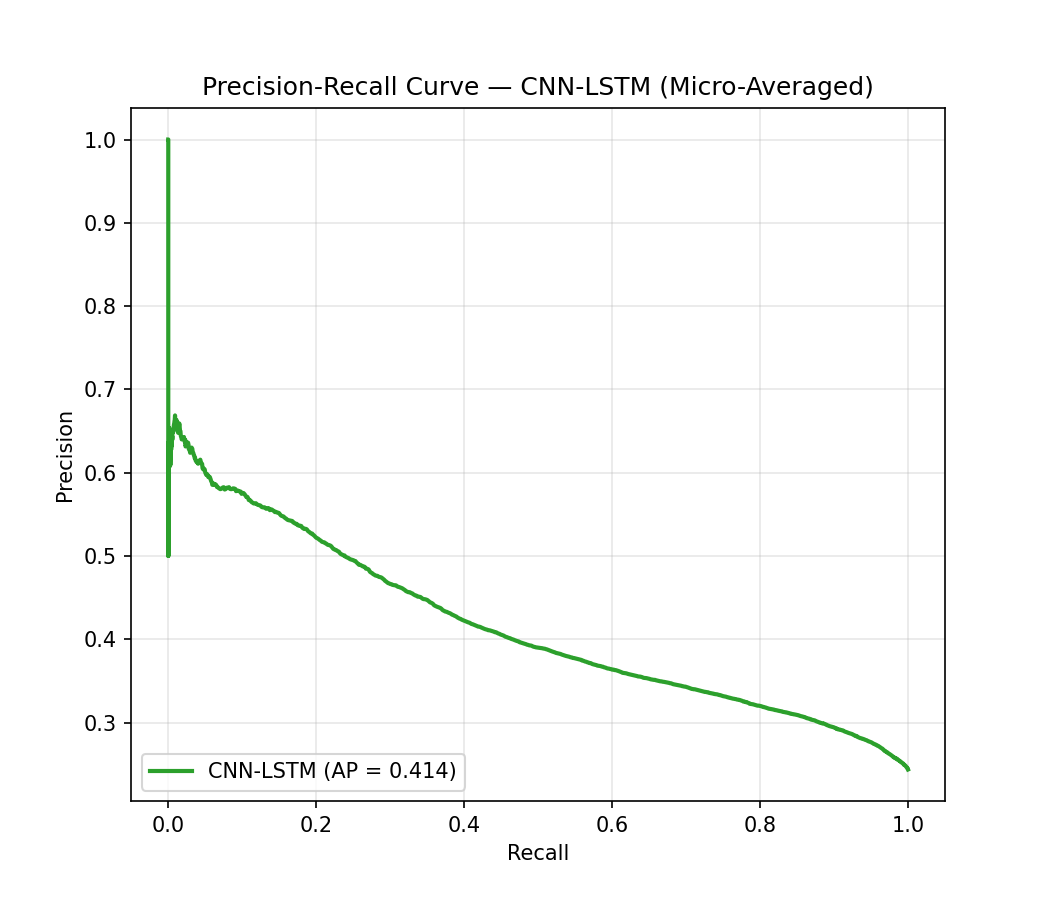

In [8]:
precision, recall, _ = precision_recall_curve(cnnlstm_test_labels.ravel(), cnnlstm_test_preds.ravel())
ap = average_precision_score(cnnlstm_test_labels, cnnlstm_test_preds, average='micro')
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'CNN-LSTM (AP = {ap:.3f})', color='tab:green', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — CNN-LSTM (Micro-Averaged)')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_pr.png'), dpi=150)
plt.show()

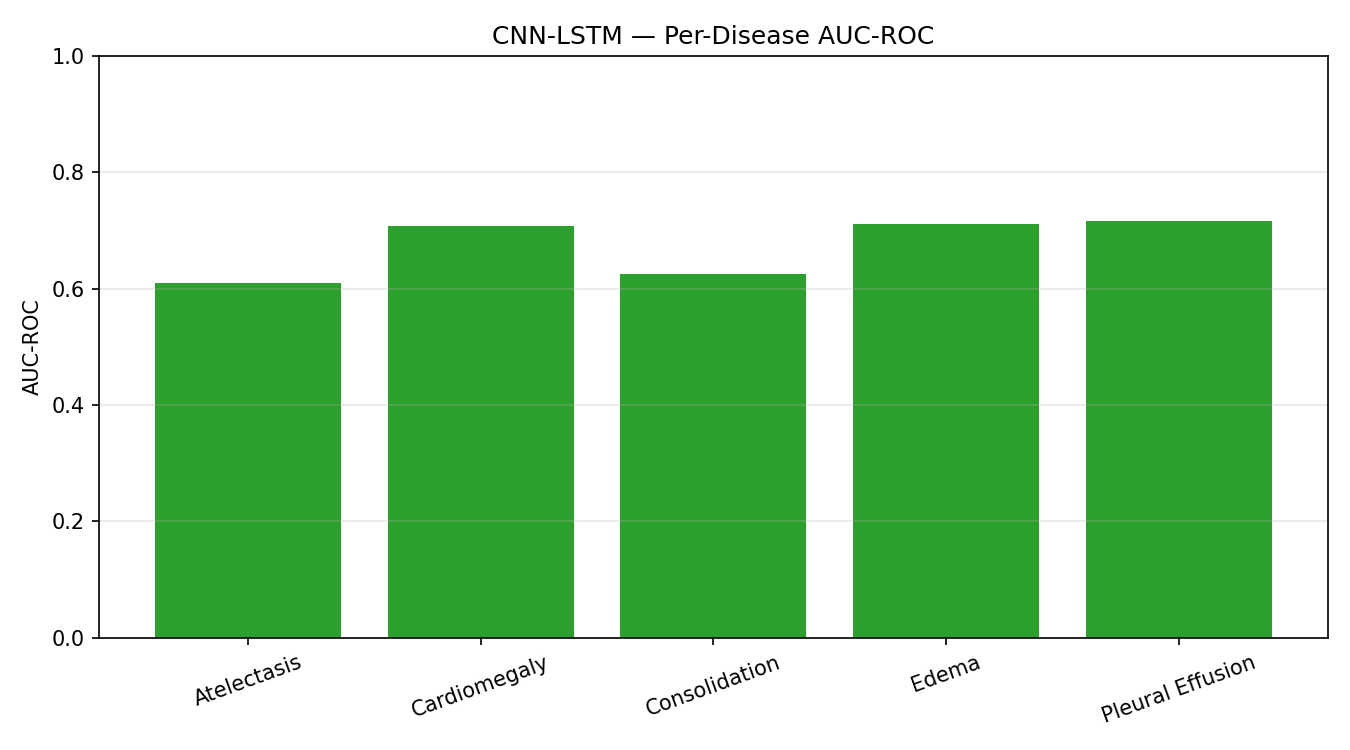

In [9]:
cnnlstm_per_disease = _per_disease_auc(cnnlstm_test_labels, cnnlstm_test_preds)
plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, cnnlstm_per_disease, color='tab:green')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('CNN-LSTM — Per-Disease AUC-ROC')
plt.xticks(rotation=20); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_per_disease_auc.png'), dpi=150)
plt.show()
for d, a in zip(DISEASE_COLS, cnnlstm_per_disease):
    print(f"{d:20s}: {a:.4f}")

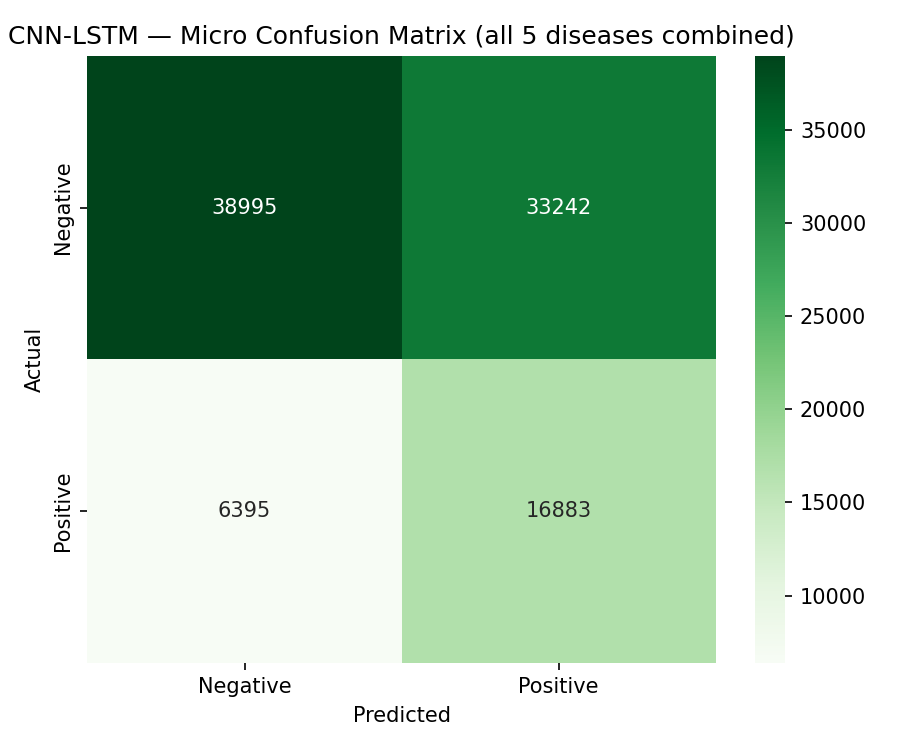

In [10]:
cnnlstm_binary_preds = (cnnlstm_test_preds >= 0.5).astype(int)
cnnlstm_cm = confusion_matrix(cnnlstm_test_labels.ravel(), cnnlstm_binary_preds.ravel())
plt.figure(figsize=(6, 5))
sns.heatmap(cnnlstm_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('CNN-LSTM — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_confusion_matrix.png'), dpi=150)
plt.show()